# 판매자 분석

판매자와 구매자 사이의 지리적 거리가 배송 경험 및 고객 만족도, 재구매 의사결정에 미치는 영향

In [1]:
# 표준 라이브러리
from pathlib import Path
import platform
from typing import List, Sequence, Any
import sys
import os

# 서드 파티 라이브러리
import pandas as pd
import numpy as np
from numpy.typing import ArrayLike
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.colors import Colormap
import seaborn as sns

## 통계 모듈
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 로컬 모듈
sys.path.append(str(Path.cwd().parent))
sys.path.append(str(Path.cwd().parent / 'src'))
from src.plot import plot_box, plot_hist, plot_stacked_bar, plot_heatmap, plot_prop_bar, plot_mean_sem, plot_scatter_jitter
from src.utils import cramers_v, interpret_cramers_v, check_expected_frequencies, standardized_residuals
from src.utils import check_normality, check_homogeneity, calculate_eta_squared, calculate_epsilon_squared, perform_dunn_test, perform_gameshowell, perform_tukey_hsd

DATA_DIR = Path('../data/processed')

In [2]:
system = platform.system()

if system == 'Windows':
    # Windows: 맑은 고딕 사용
    plt.rcParams['font.family'] = 'Malgun Gothic'
    
elif system == 'Darwin':  # Darwin = macOS
    # macOS: 애플 고딕 사용
    plt.rcParams['font.family'] = 'AppleGothic'
    
elif system == 'Linux':
    # Linux: 나눔 고딕 사용 (사전 설치 필요)
    # 터미널: sudo apt-get install -y fonts-nanum
    plt.rcParams['font.family'] = 'NanumGothic'
    
else:
    print(f"알 수 없는 OS: {system}")

# 모든 OS 공통: 음수 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print(f"OS: {system}, 설정된 폰트: {plt.rcParams['font.family']}")

OS: Linux, 설정된 폰트: ['NanumGothic']


## 데이터 불러오기

In [3]:
pandas_kwargs = {
    'parse_dates': ['purchase_time', 'approved_time', 'carrier_delivered_time', 'delivered_time', 'estimated_delivery_time'],
    'date_format': '%Y-%m-%d %H:%M:%S',
    'memory_map': True
}

processed_data = pd.read_csv(DATA_DIR / 'processed_data.csv', **pandas_kwargs)
processed_data

,category,review_score,quantity,price,freight_value,total_price,purchase_time,approved_time,carrier_delivered_time,delivered_time,...,customer_unique_id,order_id,product_id,payment_sequential,seller_id,zip_code_sell,city_sell,state_sell,latitude_sell,longitude_sell
0,가구·인테리어,4.0,1,124.99,21.88,146.87,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,...,861eff4711a542e4b93843c6dd7febb0,00e7ee1b050b8499577073aeb2a297a1,a9516a079e37a9c9c36b9b78b10169e8,1,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
1,생활용품,5.0,1,289.00,46.48,335.48,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,...,290c77bc529b7ac935b93aa66c333dc3,29150127e6685892b6eab3eec79f59c7,4aa6014eceb682077f9dc4bffebc05b0,1,b8bc237ba3788b23da09c0f1f3a3288c,88303,itajai,SC,-26.920912,-48.684937
2,가구·인테리어,5.0,1,139.94,17.79,157.73,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,...,060e732b5b29e8181a18229c7b0b2b5e,b2059ed67ce144a36e2aa97d2c9e9ad2,bd07b66896d6f1494f5b86251848ced7,1,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
3,가구·인테리어,5.0,1,149.94,23.36,173.30,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,...,259dac757896d24d7702b9acbbff3f3c,951670f92359f4fe4a63112aa7306eba,a5647c44af977b148e0a3a4751a09e2e,1,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
4,가구·인테리어,5.0,1,230.00,22.25,252.25,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,...,345ecd01c38d18a9036ed96c73b8d066,6b7d50bd145f6fc7f33cebabd7e49d0f,9391a573abe00141c56e38d84d7d5b3b,1,4a3ca9315b744ce9f8e9374361493884,14940,ibitinga,SP,-21.774868,-48.847152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101116,도서·미디어,4.0,1,74.90,13.88,88.78,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,...,1a29b476fee25c95fbafc67c5ac95cf8,6760e20addcf0121e9d58f2f1ff14298,ccb4503d9d43d245d3b295d0544f988b,1,527801b552d0077ffd170872eb49683b,17400,garca,SP,-22.210402,-49.662731
101117,스포츠·레저,5.0,1,114.90,14.16,129.06,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,...,d52a67c98be1cf6a5c84435bd38d095d,9ec0c8947d973db4f4e8dcf1fbfa8f1b,9ede6b0570a75a4b9de4f383329f99ee,1,3fd1e727ba94cfe122d165e176ce7967,14802,araraquara,SP,-21.775406,-48.168105
101118,건강·뷰티,1.0,1,37.00,19.04,56.04,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,...,e9f50caf99f032f0bf3c55141f019d99,fed4434add09a6f332ea398efd656a5c,7a5d2e1e131a860ae7d18f6fffa9d689,1,d9e7e7778b32987280a6f2cb9a39c57d,3304,sao paulo,SP,-23.545397,-46.581221
101119,패션·의류,5.0,1,689.00,22.07,711.07,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,...,73c2643a0a458b49f58cea58833b192e,e31ec91cea1ecf97797787471f98a8c2,f819f0c84a64f02d3a5606ca95edd272,1,4869f7a5dfa277a7dca6462dcf3b52b2,14840,guariba,SP,-21.369332,-48.225907


## 파생 변수 - 재구매 여부

In [4]:
grouped = processed_data.groupby('customer_unique_id', as_index=False).agg(cnt_order=('order_id', 'nunique'))
repurchase_cond = grouped['cnt_order'] > 1
grouped[repurchase_cond].size / grouped.size * 100

2.952549482238825

In [5]:
grouped[repurchase_cond]

,customer_unique_id,cnt_order
101,004288347e5e88a27ded2bb23747066c,2
295,00cc12a6d8b578b8ebd21ea4e2ae8b27,2
392,011575986092c30523ecb71ff10cb473,2
407,011b4adcd54683b480c4d841250a987f,2
452,013ef03e0f3f408dd9bf555e4edcdc0a,2
...,...,...
91189,ff03923ad1eb9e32304deb7f9b2a45c9,2
91283,ff44401d0d8f5b9c54a47374eb48c1b8,2
91381,ff8892f7c26aa0446da53d01b18df463,2
91399,ff922bdd6bafcdf99cb90d7f39cea5b3,3


In [6]:
grouped.value_counts()

customer_unique_id                cnt_order
ffffd2657e2aad2907e67c3e9daecbeb  1            1
0000366f3b9a7992bf8c76cfdf3221e2  1            1
0000b849f77a49e4a4ce2b2a4ca5be3f  1            1
0000f46a3911fa3c0805444483337064  1            1
0000f6ccb0745a6a4b88665a16c9f078  1            1
                                              ..
000c8bdb58a29e7115cfc257230fb21b  1            1
000bfa1d2f1a41876493be685390d6d3  1            1
000a5ad9c4601d2bbdd9ed765d5213b3  1            1
000949456b182f53c18b68d6babc79c1  1            1
00090324bbad0e9342388303bb71ba0a  1            1
Name: count, Length: 91548, dtype: int64

In [7]:
processed_data['is_repurchase'] = 0
processed_data.loc[grouped[repurchase_cond].index, 'is_repurchase'] = 1

In [8]:
# 구매 순서
processed_data['order_sequential'] = processed_data.groupby('customer_unique_id')['purchase_time'].rank('dense')

## 필요한 행, 컬럼 선정

행: 첫 구매 경험

고객 정보: customer 위치, 재구매 여부

판매자 정보: seller_id, seller 위치

구매 정보: 주문 일시, 승인 일시, 배송 예정일, 실제 도착일

In [9]:
sorted_data = processed_data.sort_values('purchase_time')
sorted_data.head(10)

,category,review_score,quantity,price,freight_value,total_price,purchase_time,approved_time,carrier_delivered_time,delivered_time,...,product_id,payment_sequential,seller_id,zip_code_sell,city_sell,state_sell,latitude_sell,longitude_sell,is_repurchase,order_sequential
19275,패션·의류,5.0,1,10.9,8.72,19.62,2017-01-05 11:56:06,2017-01-05 12:10:17,2017-01-06 12:43:41,2017-01-11 13:14:05,...,f5d8f4fbc70ca2a0038b9a0010ed5cb0,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,1.0
49892,자동차,5.0,1,10.9,8.72,19.62,2017-01-05 12:01:20,2017-01-07 03:35:37,2017-01-11 16:22:53,2017-01-17 15:38:58,...,6c04a068e5ab37749c980c42a036b9e3,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,1.0
44944,기타,5.0,1,2.9,8.72,11.62,2017-01-05 12:06:36,2017-01-07 03:45:22,2017-01-11 15:35:54,2017-01-16 16:05:22,...,680cc8535be7cc69544238c1d6a83fe8,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,1.0
1990,기타,5.0,1,7.9,8.72,16.62,2017-01-05 12:09:08,2017-01-07 03:44:08,2017-01-11 15:35:53,2017-01-16 15:43:29,...,c0d4027067afcf9c1697cce981b8fed6,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,2.0
46501,기타,5.0,1,9.9,8.72,18.62,2017-01-05 12:11:23,2017-01-07 03:44:07,2017-01-11 16:22:53,2017-01-17 16:06:30,...,1514ddb0f4a5afc8d24104e89c714403,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,3.0
14892,패션·의류,5.0,1,10.9,8.72,19.62,2017-01-05 12:14:58,2017-01-07 03:35:24,2017-01-11 16:09:04,2017-01-16 16:13:55,...,f5d8f4fbc70ca2a0038b9a0010ed5cb0,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,1.0
42573,기타,5.0,1,11.9,8.72,20.62,2017-01-05 13:01:48,2017-01-07 03:45:49,2017-01-11 16:08:53,2017-01-16 15:43:21,...,baddee1245c9736a49167f66e0912b0d,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,1.0
68994,패션·의류,5.0,1,10.9,8.72,19.62,2017-01-05 13:29:03,2017-01-07 03:45:23,2017-01-11 15:35:54,2017-01-16 16:05:21,...,f5d8f4fbc70ca2a0038b9a0010ed5cb0,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,1.0
43515,패션·의류,5.0,1,10.9,8.72,19.62,2017-01-05 13:31:22,2017-01-07 03:44:29,2017-01-11 15:35:53,2017-01-16 16:05:21,...,f5d8f4fbc70ca2a0038b9a0010ed5cb0,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,1.0
93002,패션·의류,5.0,1,10.9,8.72,19.62,2017-01-05 13:33:45,2017-01-07 03:44:27,2017-01-11 15:35:53,2017-01-17 16:51:39,...,f5d8f4fbc70ca2a0038b9a0010ed5cb0,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,1.0


In [10]:
# 첫 구매 경험
first_purchase = sorted_data[sorted_data['order_sequential'] == 1]

In [11]:
# 필요한 컬럼 선택
## state와 zip_code는 좌표 오류 탐지할 때 추가 
columns = ['latitude_cust', 'longitude_cust', 'seller_id', 'latitude_sell', 'longitude_sell', 'purchase_time', 'approved_time', 'delivered_time', 'estimated_delivery_time', 'state_cust', 'zip_code_cust', 'state_sell', 'is_repurchase', 'review_score']

filtered_data = first_purchase[columns].drop_duplicates().reset_index(drop=True)
filtered_data = filtered_data[filtered_data['state_sell'] != '0']
filtered_data

,latitude_cust,longitude_cust,seller_id,latitude_sell,longitude_sell,purchase_time,approved_time,delivered_time,estimated_delivery_time,state_cust,zip_code_cust,state_sell,is_repurchase,review_score
0,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.499350,-49.296911,2017-01-05 11:56:06,2017-01-05 12:10:17,2017-01-11 13:14:05,2017-02-01,PR,80030,PR,0,5.0
1,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.499350,-49.296911,2017-01-05 12:01:20,2017-01-07 03:35:37,2017-01-17 15:38:58,2017-02-13,PR,80030,PR,0,5.0
2,-25.406155,-49.257755,48efc9d94a9834137efd9ea76b065a38,-25.499350,-49.296911,2017-01-05 12:06:36,2017-01-07 03:45:22,2017-01-16 16:05:22,2017-02-13,PR,80540,PR,0,5.0
3,-25.451968,-49.267206,48efc9d94a9834137efd9ea76b065a38,-25.499350,-49.296911,2017-01-05 12:14:58,2017-01-07 03:35:24,2017-01-16 16:13:55,2017-02-01,PR,80220,PR,0,5.0
4,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.499350,-49.296911,2017-01-05 13:01:48,2017-01-07 03:45:49,2017-01-16 15:43:21,2017-02-13,PR,80030,PR,0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93270,-23.680351,-46.768105,5f2684dab12e59f83bef73ae57724e45,-23.500827,-46.738377,2018-08-29 12:25:59,2018-08-29 12:35:17,2018-08-30 22:48:27,2018-09-03,SP,5863,SP,0,1.0
93271,-25.430733,-49.255263,67bf6941ba2f1fa1d02c375766bc3e53,-25.397121,-49.353125,2018-08-29 14:18:23,2018-08-29 14:31:07,2018-08-30 16:24:55,2018-09-04,PR,80045,PR,0,5.0
93272,-17.217471,-46.872975,2a84855fd20af891be03bc5924d2b453,-19.913589,-43.939425,2018-08-29 14:18:28,2018-08-29 14:30:23,2018-08-30 16:52:31,2018-09-11,MG,38600,MG,0,5.0
93273,-23.621066,-46.564813,7d7866a99a8656a42c7ff6352a433410,-23.557888,-46.639554,2018-08-29 14:52:00,2018-08-29 15:05:22,2018-08-30 16:36:59,2018-09-03,SP,9541,SP,0,3.0


In [12]:
first_purchase[first_purchase['review_score'] != '리뷰없음']['review_score'].astype(float).astype(int).describe()

count    97332.000000
mean         4.085994
std          1.341512
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64

## 파생변수 생성 - 거리 구간

### 거리 계산

In [13]:
from haversine import haversine

# 거리 계산
def calculate_haversine(row):
    customer = (row['latitude_cust'], row['longitude_cust'])
    seller = (row['latitude_sell'], row['longitude_sell'])
    distance = haversine(customer, seller, unit='km')
    if distance > 4000:
        print(row)
    return distance

filtered_data['distance'] = filtered_data.apply(calculate_haversine, axis=1)

In [14]:
filtered_data['distance'].describe()

count    93069.000000
mean       599.846397
std        591.231221
min          0.000000
25%        185.723632
50%        433.779694
75%        798.760592
max       3399.318090
Name: distance, dtype: float64

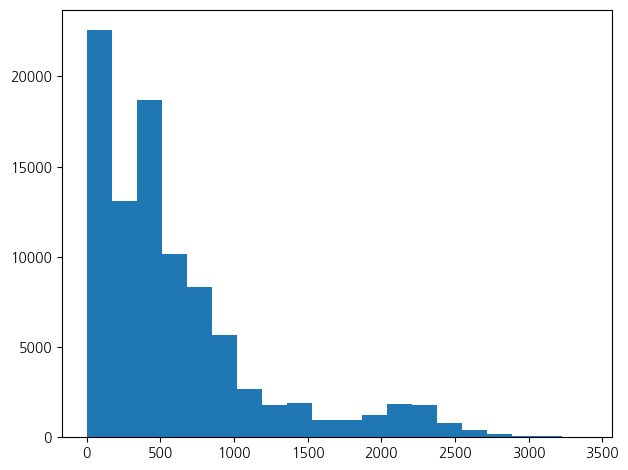

In [15]:
plt.hist(x=filtered_data['distance'], bins=20)
plt.tight_layout()
plt.show()

## 파생 변수 - 배송 시간

In [16]:
filtered_data['delivered_days'] = (filtered_data['delivered_time'] - filtered_data['purchase_time']).dt.days
filtered_data['approved_hours'] = ((filtered_data['approved_time'] - filtered_data['purchase_time']).dt.total_seconds() / 3600).round()
filtered_data['delayed_days'] = (filtered_data['delivered_time'] - filtered_data['estimated_delivery_time']).dt.days

filtered_data.head(10)

,latitude_cust,longitude_cust,seller_id,latitude_sell,longitude_sell,purchase_time,approved_time,delivered_time,estimated_delivery_time,state_cust,zip_code_cust,state_sell,is_repurchase,review_score,distance,delivered_days,approved_hours,delayed_days
0,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 11:56:06,2017-01-05 12:10:17,2017-01-11 13:14:05,2017-02-01,PR,80030,PR,0,5.0,10.337962,6,0.0,-21
1,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 12:01:20,2017-01-07 03:35:37,2017-01-17 15:38:58,2017-02-13,PR,80030,PR,0,5.0,10.337962,12,40.0,-27
2,-25.406155,-49.257755,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 12:06:36,2017-01-07 03:45:22,2017-01-16 16:05:22,2017-02-13,PR,80540,PR,0,5.0,11.083577,11,40.0,-28
3,-25.451968,-49.267206,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 12:14:58,2017-01-07 03:35:24,2017-01-16 16:13:55,2017-02-01,PR,80220,PR,0,5.0,6.053982,11,39.0,-16
4,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 13:01:48,2017-01-07 03:45:49,2017-01-16 15:43:21,2017-02-13,PR,80030,PR,0,5.0,10.337962,11,39.0,-28
5,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 13:29:03,2017-01-07 03:45:23,2017-01-16 16:05:21,2017-02-01,PR,80030,PR,0,5.0,10.337962,11,38.0,-16
6,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 13:31:22,2017-01-07 03:44:29,2017-01-16 16:05:21,2017-02-01,PR,80030,PR,0,5.0,10.337962,11,38.0,-16
7,-25.390224,-49.209119,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 13:33:45,2017-01-07 03:44:27,2017-01-17 16:51:39,2017-02-01,PR,82600,PR,0,5.0,14.998239,12,38.0,-15
8,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 13:34:35,2017-01-07 03:45:40,2017-01-17 15:52:28,2017-02-13,PR,80030,PR,0,5.0,10.337962,12,38.0,-27
9,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 13:36:41,2017-01-07 03:44:29,2017-01-16 15:53:34,2017-02-01,PR,80030,PR,0,5.0,10.337962,11,38.0,-16


## 파생변수 - 배송 효율

In [17]:
filtered_data['delivery_efficiency'] = np.log1p(filtered_data['delivered_days']) - np.log1p(filtered_data['distance'])

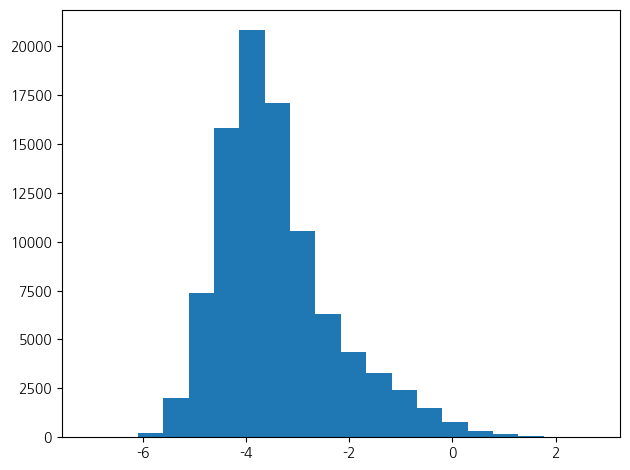

In [18]:
plt.hist(x=filtered_data['delivery_efficiency'], bins=20)
plt.tight_layout()
plt.show()

## 파생변수 - 리뷰

In [19]:
plus_review = filtered_data.copy()
plus_review['no_review'] = 1
plus_review.loc[plus_review['review_score'] == '리뷰없음', 'no_review'] = 0
plus_review.loc[plus_review['review_score'] == '리뷰없음', 'review_score'] = np.nan
plus_review['review_score'] = plus_review['review_score'].astype(float)
plus_review.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93069 entries, 0 to 93274
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   latitude_cust            93069 non-null  float64       
 1   longitude_cust           93069 non-null  float64       
 2   seller_id                93069 non-null  object        
 3   latitude_sell            93069 non-null  float64       
 4   longitude_sell           93069 non-null  float64       
 5   purchase_time            93069 non-null  datetime64[ns]
 6   approved_time            93069 non-null  datetime64[ns]
 7   delivered_time           93069 non-null  datetime64[ns]
 8   estimated_delivery_time  93069 non-null  datetime64[ns]
 9   state_cust               93069 non-null  object        
 10  zip_code_cust            93069 non-null  int64         
 11  state_sell               93069 non-null  object        
 12  is_repurchase            93069 non-nu

In [20]:
# # 리뷰 부정적, 긍정적 분류
# plus_review['review_score'] = plus_review['review_score'].map({1.0: 0, 2.0: 0, 3.0: 0, 4.0: 1, 5.0: 1})

In [21]:
# 파생변수 생성 끝난 데이터
data: pd.DataFrame = plus_review.copy()

## 기술 통계

In [22]:
data['distance'].describe()

count    93069.000000
mean       599.846397
std        591.231221
min          0.000000
25%        185.723632
50%        433.779694
75%        798.760592
max       3399.318090
Name: distance, dtype: float64

#### 거리 구간 설정

In [23]:
# 일반 분할

bins = [0, 100, 500, 1000, 2000, 4400]
labels = [
    '근거리 (0-100km)',
    '인근 (100-500km)',
    '중거리 (500-1,000km)',
    '장거리 (1,000-2,000km)',
    '초장거리 (2,000km+)'
]
data['distance_label'] = pd.cut(data['distance'], bins=bins, right=False, labels=labels)

In [24]:
group1 = data.groupby('distance_label', observed=True).agg(
    개수=('distance_label', 'size'),
    평균거리=('distance', 'mean'),
    평균배달일=('delivered_days', 'mean'),
    평균승인시간=('approved_hours', 'mean'),
    평균지연일=('delayed_days', 'mean'),
    # 평균배달효율=('delivery_efficiency', 'mean'),
    평균평점=('review_score', 'mean'),
    리뷰=('no_review', 'sum'),
    재구매=('is_repurchase', 'sum')
)

group1['재구매율'] = (group1['재구매'] / group1['개수'] * 100).round(2)
group1['리뷰작성율'] = (group1['리뷰'] / group1['개수'] * 100).round(2)
group1.round(2)

,개수,평균거리,평균배달일,평균승인시간,평균지연일,평균평점,리뷰,재구매,재구매율,리뷰작성율
distance_label,,,,,,,,,,
근거리 (0-100km),17335,40.06,6.01,9.49,-9.50,4.26,17226,447,2.58,99.37
인근 (100-500km),35906,322.65,10.96,9.76,-12.08,4.16,35682,1023,2.85,99.38
"중거리 (500-1,000km)",24987,712.41,13.77,10.59,-12.68,4.09,24816,714,2.86,99.32
"장거리 (1,000-2,000km)",9434,1402.25,17.46,11.13,-12.86,4.04,9366,277,2.94,99.28
"초장거리 (2,000km+)",5407,2315.06,20.67,12.12,-12.59,3.96,5358,139,2.57,99.09


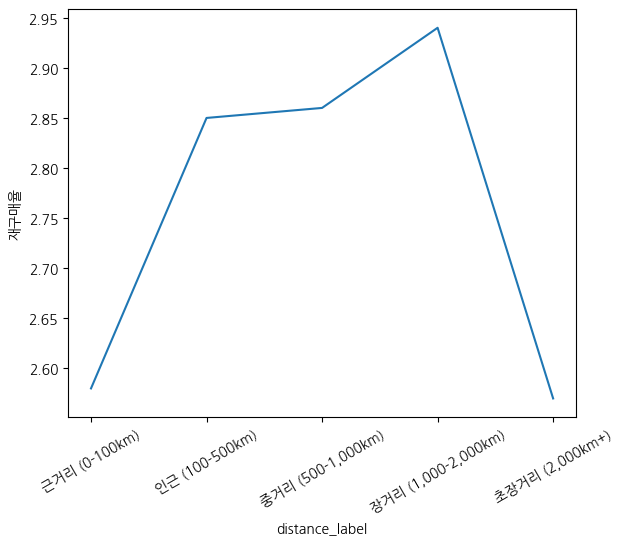

In [25]:
sns.lineplot(group1['재구매율'])
plt.tight_layout()
plt.xticks(rotation=30)
plt.show()

In [26]:
# 분위수 기반 분할

def cut_groupq(data: pd.DataFrame, qnum=4):
    labels = [f'Q{i+1}' for i in range(qnum)]
    data['distance_quartile'] = pd.qcut(data['distance'], qnum, labels=labels)
    

def gen_groupq(data: pd.DataFrame):
    group2 = data.groupby('distance_quartile', observed=True).agg(
        개수=('distance_quartile', 'size'),
        평균거리=('distance', 'mean'),
        평균배달소요일=('delivered_days', 'mean'),
        평균승인소요시간=('approved_hours', 'mean'),
        평균지연시간=('delayed_days', 'mean'),
        평균배달효율=('delivery_efficiency', 'mean'),
        평균평점=('review_score', 'mean'),
        리뷰=('no_review', 'sum'),
        재구매=('is_repurchase', 'sum')
    )

    group2['재구매율'] = (group2['재구매'] / group2['개수'] * 100).round(2)
    group2['리뷰작성율'] = (group2['리뷰'] / group2['개수'] * 100).round(2)
    return group2
    

,개수,평균거리,평균배달소요일,평균승인소요시간,평균지연시간,평균배달효율,평균평점,리뷰,재구매,재구매율,리뷰작성율
distance_quartile,,,,,,,,,,,
Q1,23268,65.099242,6.542247,9.650335,-9.925993,-1.970277,4.266975,23122,630,2.71,99.37
Q2,23267,327.371863,11.399880,9.608802,-12.202261,-3.406690,4.132944,23115,640,2.75,99.35
Q3,23267,582.800568,13.124511,10.278893,-12.359522,-3.844495,4.092605,23109,669,2.88,99.32
Q4,23267,1424.136898,16.991619,11.298105,-12.992049,-4.427193,4.044758,23102,661,2.84,99.29


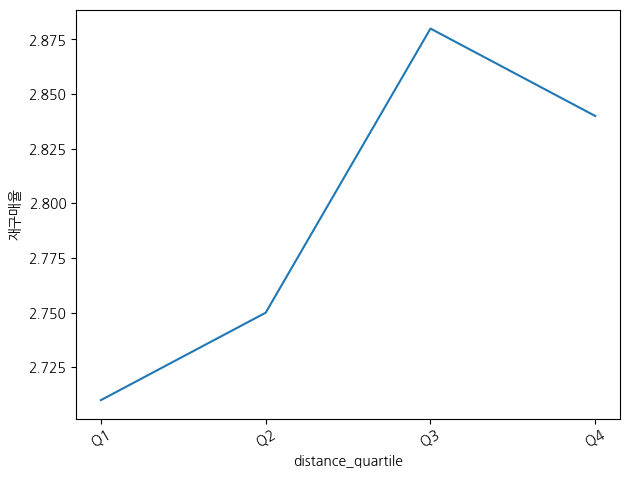

,개수,평균거리,평균배달소요일,평균승인소요시간,평균지연시간,평균배달효율,평균평점,리뷰,재구매,재구매율,리뷰작성율
distance_quartile,,,,,,,,,,,
Q1,18614,44.694605,6.124637,9.517353,-9.562534,-1.729126,4.258124,18495,479,2.57,99.36
Q2,18614,253.411923,10.394005,9.781777,-11.877726,-3.216781,4.168667,18498,537,2.88,99.38
Q3,18613,433.332055,11.944233,9.788642,-12.427013,-3.652617,4.132313,18494,530,2.85,99.36
Q4,18614,697.195795,13.797196,10.578167,-12.569518,-3.972352,4.081616,18489,538,2.89,99.33
Q5,18614,1570.588661,17.812453,11.379177,-12.912915,-4.489879,4.030858,18472,516,2.77,99.24


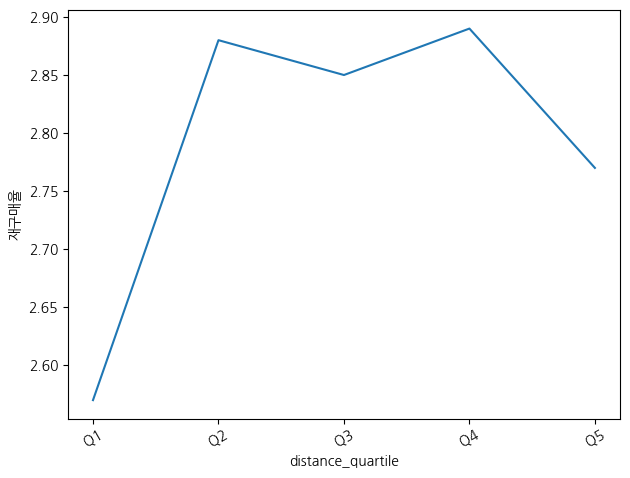

,개수,평균거리,평균배달소요일,평균승인소요시간,평균지연시간,평균배달효율,평균평점,리뷰,재구매,재구매율,리뷰작성율
distance_quartile,,,,,,,,,,,
Q1,15512,33.925648,5.889634,9.556150,-9.524110,-1.538398,4.257786,15412,406,2.62,99.36
Q2,15511,192.299592,9.223325,9.771517,-11.265425,-3.032581,4.223166,15419,432,2.79,99.41
Q3,15512,362.472710,11.800090,9.561050,-12.402785,-3.494447,4.118915,15406,432,2.78,99.32
Q4,15511,518.040677,12.540842,10.043260,-12.388821,-3.783691,4.093669,15416,455,2.93,99.39
Q5,15511,790.180048,14.171427,10.820321,-12.814906,-4.074880,4.094969,15405,438,2.82,99.32
Q6,15512,1702.140430,18.461707,11.501870,-12.823620,-4.548934,4.017349,15390,437,2.82,99.21


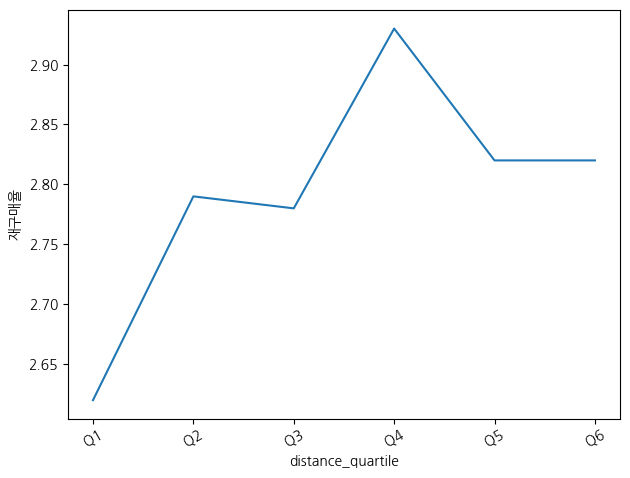

,개수,평균거리,평균배달소요일,평균승인소요시간,평균지연시간,평균배달효율,평균평점,리뷰,재구매,재구매율,리뷰작성율
distance_quartile,,,,,,,,,,,
Q1,13296,26.872023,5.751053,9.495337,-9.475782,-1.379485,4.264425,13206,356,2.68,99.32
Q2,13295,142.255070,8.274991,9.847537,-10.891012,-2.846446,4.253971,13222,345,2.59,99.45
Q3,13296,319.236884,11.450211,9.511282,-12.158619,-3.396703,4.103824,13205,381,2.87,99.32
Q4,13295,433.024815,11.912599,9.816397,-12.427228,-3.655171,4.141041,13216,388,2.92,99.41
Q5,13296,595.302694,13.443291,10.150120,-12.242930,-3.851905,4.075845,13198,372,2.80,99.26
Q6,13296,867.799385,14.305656,11.071977,-13.250903,-4.157958,4.097790,13212,384,2.89,99.37
Q7,13295,1814.478300,18.963971,11.570590,-12.643099,-4.597435,4.003184,13189,374,2.81,99.20


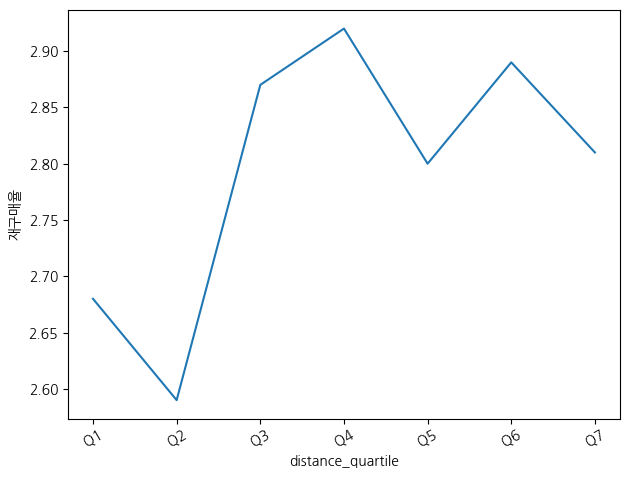

,개수,평균거리,평균배달소요일,평균승인소요시간,평균지연시간,평균배달효율,평균평점,리뷰,재구매,재구매율,리뷰작성율
distance_quartile,,,,,,,,,,,
Q1,11634,22.318193,5.650593,9.397370,-9.433041,-1.253263,4.265836,11556,308,2.65,99.33
Q2,11634,107.880292,7.433901,9.903301,-10.418944,-2.687291,4.268113,11566,322,2.77,99.42
Q3,11633,278.362890,11.002149,9.740050,-11.914983,-3.281882,4.119886,11561,314,2.70,99.38
Q4,11634,376.376624,11.797576,9.477566,-12.489513,-3.531488,4.146010,11554,326,2.80,99.31
Q5,11633,494.271828,12.146996,10.061377,-12.499183,-3.770305,4.120166,11559,343,2.95,99.36
Q6,11634,671.321698,14.101943,10.496390,-12.219873,-3.918679,4.065022,11550,326,2.80,99.28
Q7,11633,938.579535,14.626837,10.859108,-13.403851,-4.218519,4.094353,11563,339,2.91,99.40
Q8,11634,1909.652525,19.356197,11.737064,-12.580282,-4.635850,3.995060,11539,322,2.77,99.18


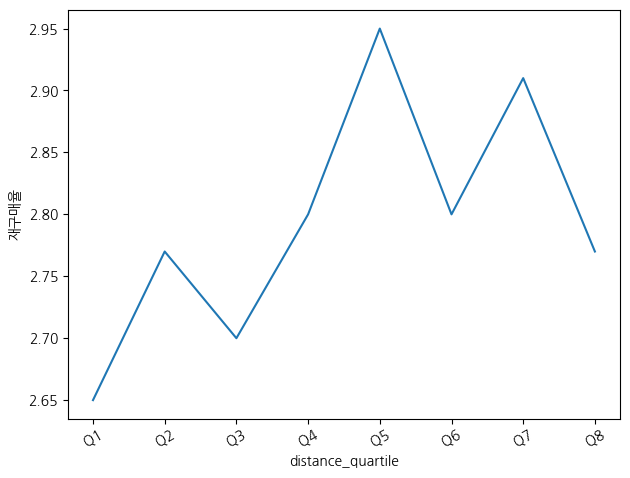

In [27]:
for i in range(4, 9):
    cut_groupq(data, i)
    group2 = gen_groupq(data)
    display(group2)
    sns.lineplot(group2['재구매율'])
    plt.tight_layout()
    plt.xticks(rotation=30)
    plt.show()
    

In [28]:
cut_groupq(data, 7)

## 시각화 함수

## 통계 분석



### 배송거리와 재구매의 독립성 - 카이제곱

In [29]:
group = pd.DataFrame()

print("\n[분할표 (Contingency Table)]")
group['재구매 O'] = group2['재구매'] 
group['재구매 X'] = group2['개수'] - group2['재구매']
group


[분할표 (Contingency Table)]


,재구매 O,재구매 X
distance_quartile,,
Q1,308,11326
Q2,322,11312
Q3,314,11319
Q4,326,11308
Q5,343,11290
Q6,326,11308
Q7,339,11294
Q8,322,11312


/home/yeeun/Sparta/Project2/src/plot.py:51: UserWarning: 'color' and 'colormap' cannot be used simultaneously. Using 'color'
  data.T.plot(kind='bar', stacked=True, ax=ax, colormap=cmap, color=colors)


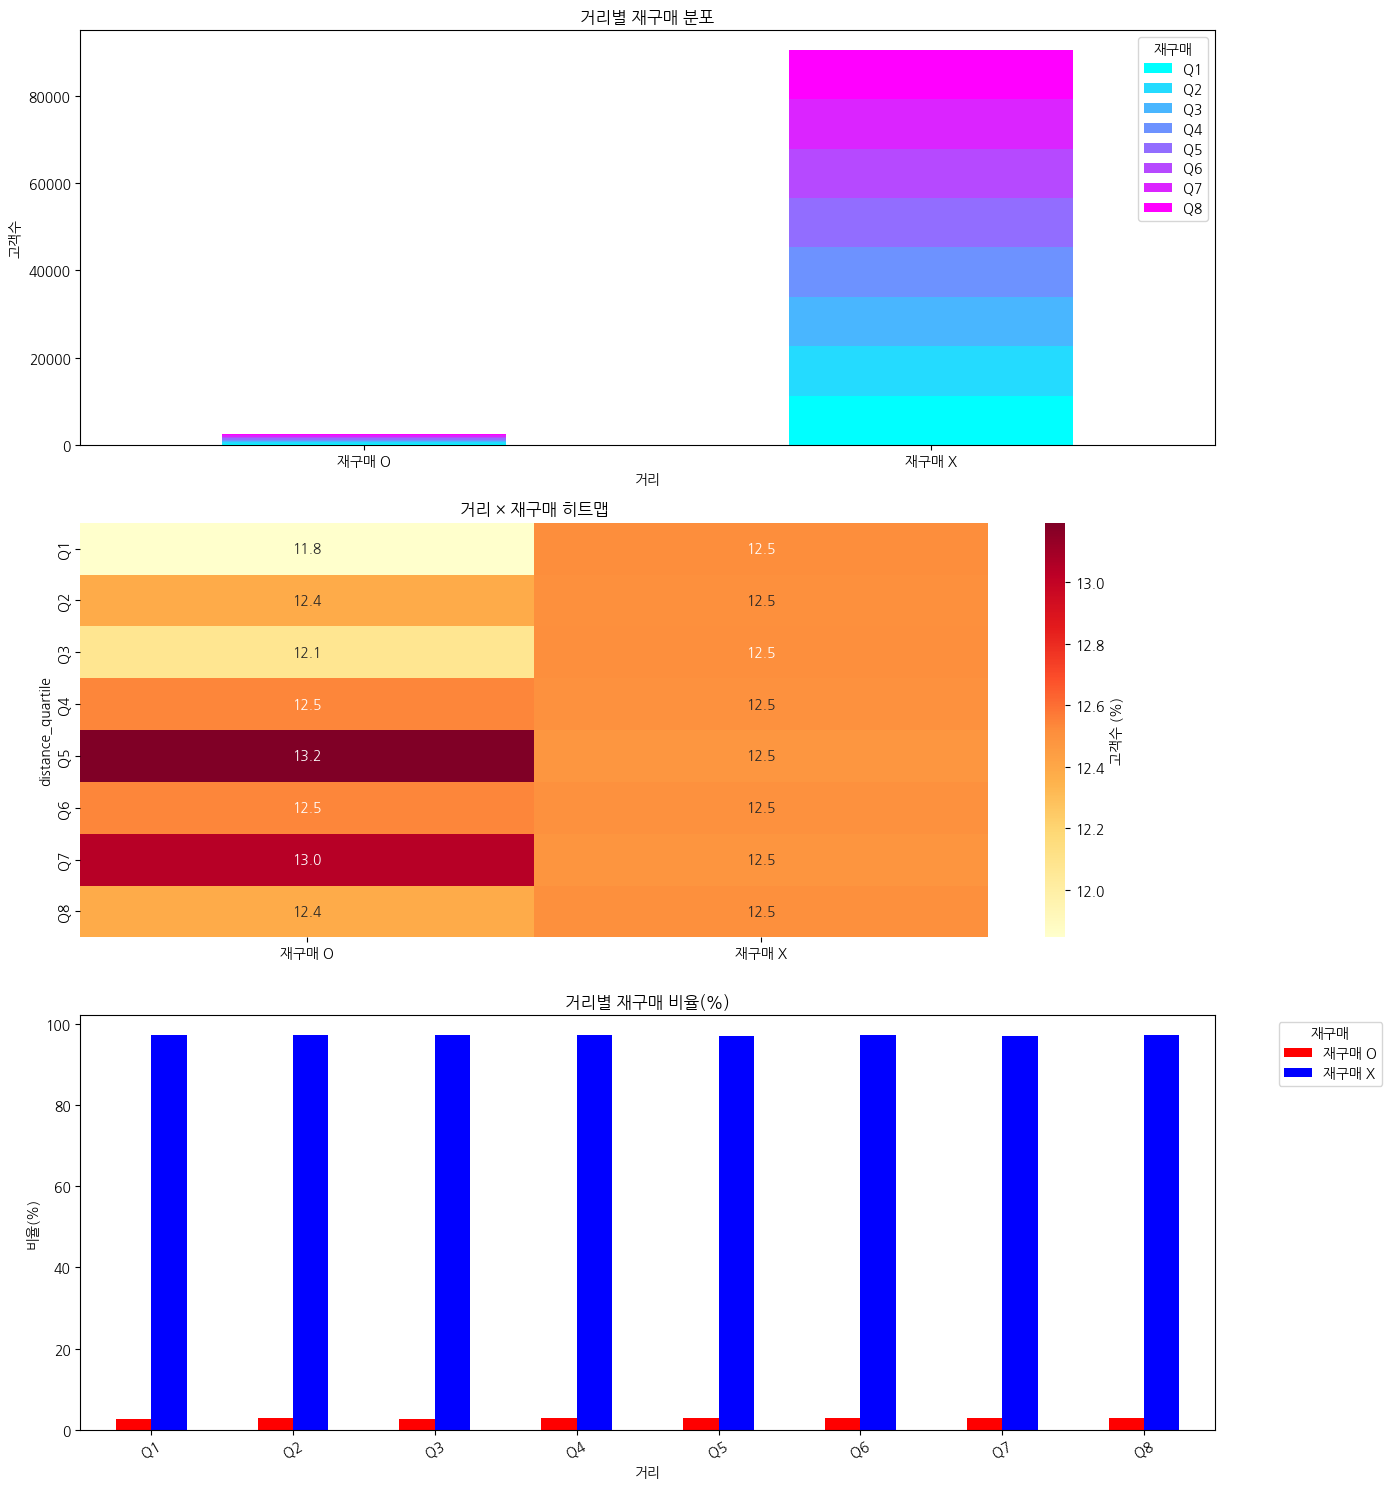

In [30]:
# 색상 목록 정의 (RGB 튜플 또는 16진수 코드 사용)
distance_colormap = 'cool'

repurchase_colors = ['red','blue']

var1 = '거리'
var2 = '재구매'
label = '고객수'


# TODO: 1. 데이터 시각화
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# 누적 막대그래프
plot_stacked_bar(group, axes[0], var1, var2, label, cmap=distance_colormap)

# 히트맵
plot_heatmap(group, axes[1], var1, var2, label, normalize='column')


# 비율 막대그래프
plot_prop_bar(group, axes[2], var1, var2, repurchase_colors, xrotation=30)


plt.tight_layout()
plt.show()

In [31]:
# 기대빈도 확인 (카이제곱 적절성 판단)
is_valid = check_expected_frequencies(group)


[기대빈도 확인]
----------------------------------------
최소 기대빈도: 324.98
5 미만 셀: 0/16 (0.0%)
✅ 카이제곱검정 사용 가능


In [32]:
# 적절한 검정 선택 및 수행 

print("\n[카이제곱 독립성 검정]")
print('-'*40)

alpha = 0.05

# 가설 설정
print(f"H₀: {var1} & {var2} - 독립적이다")
print(f"H₁: {var1} & {var2} - 관련이 있다")
print(f"유의수준: α = {alpha}")


chi2_stat, p_value, dof, expected = chi2_contingency(group)

print(f"\n카이제곱 통계량: {chi2_stat:.4f}")
print(f"자유도: {dof}")  # df = (행수-1) × (열수-1)
print(f"p-value: {p_value:.4f}")


[카이제곱 독립성 검정]
----------------------------------------
H₀: 거리 & 재구매 - 독립적이다
H₁: 거리 & 재구매 - 관련이 있다
유의수준: α = 0.05

카이제곱 통계량: 3.0109
자유도: 7
p-value: 0.8840


In [33]:
# 효과 크기 계산

n = group.values.sum()
r, c = group.shape
v = cramers_v(chi2_stat, n, r, c)

print(f"Cramér's V: {v:.3f} ({interpret_cramers_v(v)})")

Cramér's V: 0.006 (매우 약한 관계)


In [34]:
# 잔차 분석 또는 Odds 분석 (필요한 경우)

expected_df = pd.DataFrame(expected, 
                           index=group.index,
                           columns=group.columns)
print("\n[기대빈도]")
display(expected_df.round(2))


# 각 셀이 독립성 가정에서 얼마나 벗어났는지 측정
# 표준화 잔차 = (관측값 - 기대값) / sqrt(기대값)
std_residuals = standardized_residuals(group.values, expected)
residuals_df = pd.DataFrame(std_residuals,
                            index=group.index,
                            columns=group.columns)
print("\n[표준화 잔차]")
display(residuals_df.round(2))
print("(|잔차| > 2: 유의한 차이, |잔차| > 3: 매우 강한 연관성)")


[기대빈도]


,재구매 O,재구매 X
distance_quartile,,
Q1,325.01,11308.99
Q2,325.01,11308.99
Q3,324.98,11308.02
Q4,325.01,11308.99
Q5,324.98,11308.02
Q6,325.01,11308.99
Q7,324.98,11308.02
Q8,325.01,11308.99



[표준화 잔차]


,재구매 O,재구매 X
distance_quartile,,
Q1,-0.94,0.16
Q2,-0.17,0.03
Q3,-0.61,0.10
Q4,0.05,-0.01
Q5,1.00,-0.17
Q6,0.05,-0.01
Q7,0.78,-0.13
Q8,-0.17,0.03


(|잔차| > 2: 유의한 차이, |잔차| > 3: 매우 강한 연관성)


In [35]:
# 해석

print("\n[결론]")

# p-value를 유의수준과 비교하여 가설 채택/기각 결정
if p_value < 0.05:
    print(f"✅ p-value({p_value:.4f}) < 0.05 → 귀무가설 기각")
    print(f"   {var1} & {var2} - 관련이 있다")
    print(f"   효과 크기: {interpret_cramers_v(v)}")
    
    # -------------------------------------------------------------------------
    # 6. 사후 분석 (Post-hoc Analysis)
    # -------------------------------------------------------------------------
    # 표준화 잔차를 통해 어느 조합이 특히 연관성이 강한지 분석
    print("\n[구체적 패턴 분석]")
    print("   표준화 잔차 |값| > 2인 셀 해석:")
    
    for i, grade in enumerate(group.index):
        for j, lang in enumerate(group.columns):
            # |잔차| > 2: 해당 조합이 독립성에서 유의하게 벗어남
            if abs(std_residuals[i, j]) > 2:
                if std_residuals[i, j] > 0:
                    # 양수: 관측값 > 기대값 (과대 표현)
                    print(f"   • {grade} - {lang}: 예상보다 선호도 높음 (잔차={std_residuals[i, j]:.2f})")
                else:
                    # 음수: 관측값 < 기대값 (과소 표현)
                    print(f"   • {grade} - {lang}: 예상보다 선호도 낮음 (잔차={std_residuals[i, j]:.2f})")
else:
    print(f"❌ p-value({p_value:.4f}) ≥ 0.05 → 귀무가설 채택")
    print(f"   {var1} & {var2} - 독립적이다")
    print(f"   ({var1} -> {var2}에 영향을 주지 않음)")


[결론]
❌ p-value(0.8840) ≥ 0.05 → 귀무가설 채택
   거리 & 재구매 - 독립적이다
   (거리 -> 재구매에 영향을 주지 않음)


### 배송 거리와 평점 - 상관 분석

In [36]:
clean_data = data.dropna()

In [37]:
from imblearn.over_sampling import SMOTE



In [38]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92448 entries, 0 to 93274
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   latitude_cust            92448 non-null  float64       
 1   longitude_cust           92448 non-null  float64       
 2   seller_id                92448 non-null  object        
 3   latitude_sell            92448 non-null  float64       
 4   longitude_sell           92448 non-null  float64       
 5   purchase_time            92448 non-null  datetime64[ns]
 6   approved_time            92448 non-null  datetime64[ns]
 7   delivered_time           92448 non-null  datetime64[ns]
 8   estimated_delivery_time  92448 non-null  datetime64[ns]
 9   state_cust               92448 non-null  object        
 10  zip_code_cust            92448 non-null  int64         
 11  state_sell               92448 non-null  object        
 12  is_repurchase            92448 non-nu

In [39]:
df_corr = clean_data[['review_score', 'distance', 'delivered_days', 'approved_hours', 'delayed_days']].copy()
df_corr

,review_score,distance,delivered_days,approved_hours,delayed_days
0,5.0,10.337962,6,0.0,-21
1,5.0,10.337962,12,40.0,-27
2,5.0,11.083577,11,40.0,-28
3,5.0,6.053982,11,39.0,-16
4,5.0,10.337962,11,39.0,-28
...,...,...,...,...,...
93270,1.0,20.190753,1,0.0,-4
93271,5.0,10.515391,1,0.0,-5
93272,5.0,430.661157,1,0.0,-12
93273,3.0,10.361441,1,0.0,-4


In [40]:
corr = df_corr.corr()
corr

,review_score,distance,delivered_days,approved_hours,delayed_days
review_score,1.000000,-0.057842,-0.322800,-0.015942,-0.255871
distance,-0.057842,1.000000,0.397551,0.034497,-0.076422
delivered_days,-0.322800,0.397551,1.000000,0.080142,0.610666
approved_hours,-0.015942,0.034497,0.080142,1.000000,0.041852
delayed_days,-0.255871,-0.076422,0.610666,0.041852,1.000000


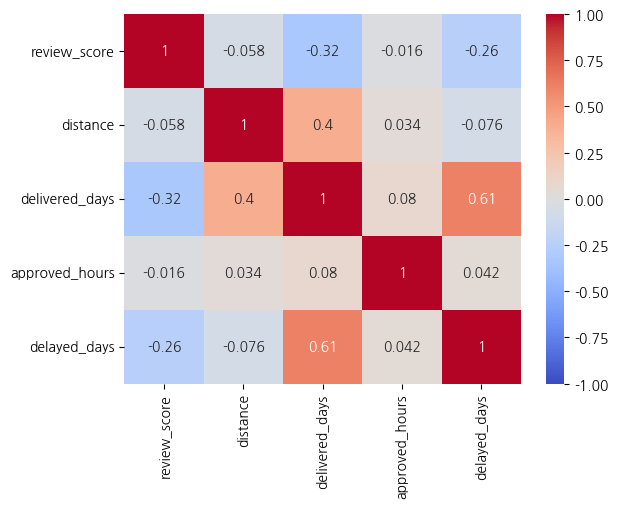

In [41]:
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

#### 다중공선성

In [42]:
X = clean_data[['distance', 'delivered_days', 'approved_hours', 'delayed_days']].copy()

# 상수항 추가
X = sm.add_constant(X)

# VIF 계산
vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df)

         variable       VIF
0           const  9.275807
1        distance  1.471711
2  delivered_days  2.340995
3  approved_hours  1.006547
4    delayed_days  1.976124


In [43]:
import statsmodels.api as sm

vars = ['distance', 'delivered_days', 'approved_hours', 'delayed_days']
for var in vars:
    print("-"*30, f' 변수: {var} ', "-"*30)
    print()
    X = clean_data[var]
    y = clean_data["review_score"]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    print(model.summary())

------------------------------  변수: distance  ------------------------------

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     310.3
Date:                Mon, 20 Oct 2025   Prob (F-statistic):           2.40e-69
Time:                        01:42:23   Log-Likelihood:            -1.5544e+05
No. Observations:               92448   AIC:                         3.109e+05
Df Residuals:                   92446   BIC:                         3.109e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

In [44]:
vars = ['distance', 'delivered_days', 'approved_hours', 'delayed_days']
X = clean_data[vars]
y = clean_data["review_score"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     2921.
Date:                Mon, 20 Oct 2025   Prob (F-statistic):               0.00
Time:                        01:42:23   Log-Likelihood:            -1.5009e+05
No. Observations:               92448   AIC:                         3.002e+05
Df Residuals:                   92443   BIC:                         3.002e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              4.4623      0.012    363.

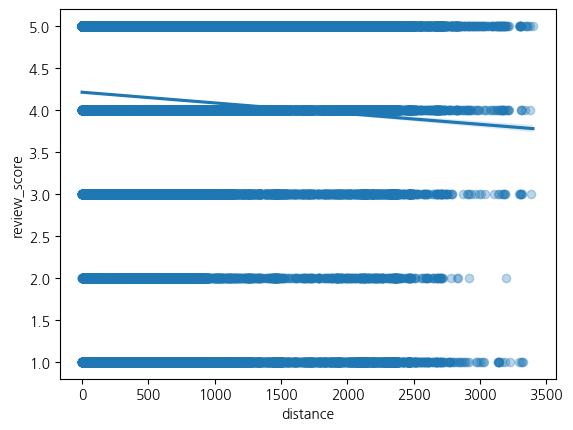

In [45]:
sns.regplot(x="distance", y="review_score", data=clean_data, scatter_kws={"alpha":0.3})
plt.show()

In [46]:
from scipy.stats import spearmanr

# 거리와 리뷰 점수의 순위 상관
corr, p_value = spearmanr(clean_data['distance'], clean_data['review_score'])
print(f"Spearman 상관계수: {corr:.4f}, p-value: {p_value:.4f}")

Spearman 상관계수: -0.0648, p-value: 0.0000


### 불균형 조정

In [47]:
# clean_data = clean_data[['distance', 'review_score']]

# import pandas as pd
# from imblearn.over_sampling import SMOTE
# from collections import Counter

# # Step 1: X와 y 분리
# X = clean_data[['distance']]  # 독립변수 (2차원 배열로 유지)
# y = clean_data['review_score']  # 종속변수 (타겟)

# # Step 2: 원본 분포 확인
# print("SMOTE 적용 전:")
# print(f"데이터 개수: {len(y)}")
# print(f"클래스 분포:\n{Counter(y)}")

# # Step 3: SMOTE 적용
# smote = SMOTE(random_state=42)
# X_resampled, y_resampled = smote.fit_resample(X, y)

# # Step 4: 결과 확인
# print("\nSMOTE 적용 후:")
# print(f"데이터 개수: {len(y_resampled)}")
# print(f"클래스 분포:\n{Counter(y_resampled)}")

# # Step 5: 하나의 DataFrame으로 합치기
# balanced_data = pd.DataFrame({
#     'distance': X_resampled.to_numpy().flatten(),  # 1차원 배열로 변환
#     'review_score': y_resampled
# })

# print("\n✅ 균형 맞춘 데이터프레임 생성 완료!")
# print(balanced_data.head())
# print(f"\n최종 데이터 형태: {balanced_data.shape}")

In [48]:
# bins = [0, 100, 500, 1000, 2000, 4400]
# labels = [
#     '근거리 (0-100km)',
#     '인근 (100-500km)',
#     '중거리 (500-1,000km)',
#     '장거리 (1,000-2,000km)',
#     '초장거리 (2,000km+)'
# ]
# balanced_data['distance_label'] = pd.cut(balanced_data['distance'], bins=bins, right=False, labels=labels)
# clean_data = balanced_data.copy()

In [49]:
# clean_data['review_score'].value_counts()

#### Anova 분석

In [50]:
labels = clean_data['distance_label'].cat.categories.tolist()
anova_data = [clean_data[clean_data['distance_label'] == i]['review_score'] for i in labels]

# 색상 목록 정의 (RGB 튜플 또는 16진수 코드 사용)
distance_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57']

review_colormap = 'hot'

var1 = '거리'
var2 = '리뷰'
label = '고객수'

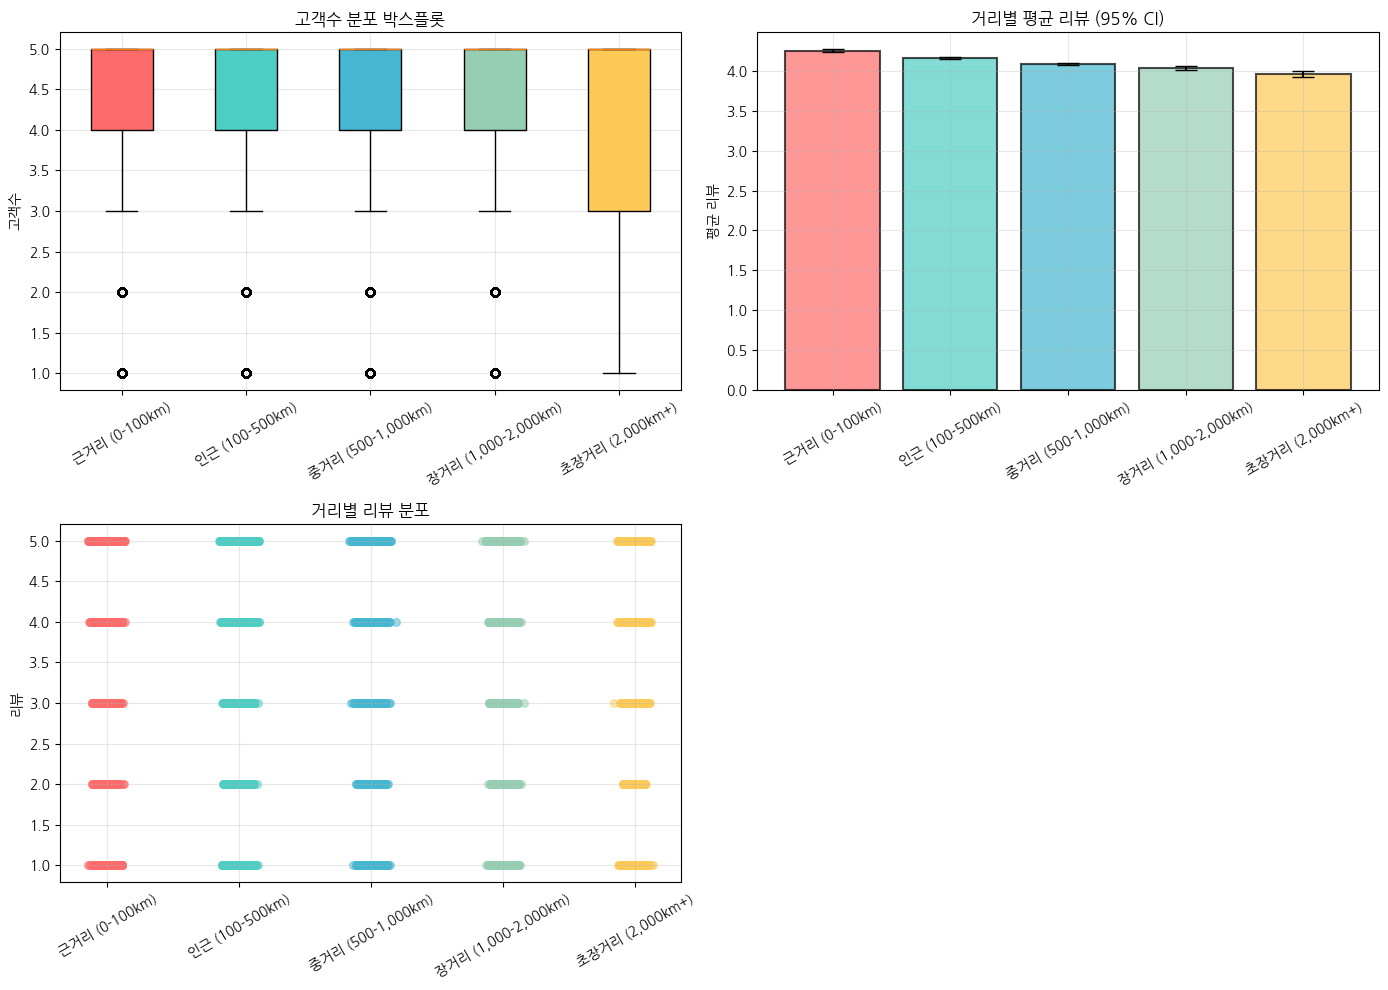

In [51]:
# 종합 시각화
fig = plt.figure(figsize=(14, 10))
ax1 = plt.subplot(2, 2, 1)

# 박스플롯

plot_box(ax1, anova_data, tick_labels=labels, ylabel=label, color=distance_colors, xrotation=30)

# 평균 및 오차막대
ax2 = plt.subplot(2, 2, 2)
plot_mean_sem(anova_data, ax2, var1, var2, labels, distance_colors, 30)

# 산점도 with jitter
ax3 = plt.subplot(2, 2, 3)
plot_scatter_jitter(anova_data, ax3, var1, var2, labels, distance_colors, xrotation=30)

# # 밀도 플롯
# ax4 = plt.subplot(2, 2, 4)
# for region, data, color in zip(regions, anova_data, colors):
#     density = stats.gaussian_kde(data)
#     x_range = np.linspace(data.min() - 20, data.max() + 20, 100)
#     ax4.plot(x_range, density(x_range), label=region, color=color, linewidth=2)
# ax4.set_title('지역별 사용시간 밀도 분포')
# ax4.set_xlabel('사용시간(분)')
# ax4.set_ylabel('밀도')
# ax4.legend()
# ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [52]:
# =============================================================================
# ANOVA 분석 수행
# =============================================================================
print("\n[일원배치 ANOVA]")
print("-"*50)

print(f"H₀: {var1}마다 평균 {var2} 모두 같다")
print(f"H₁: 적어도 한 {var1}의 평균{var2} 다르다")
print("유의수준: α = 0.05")

# -----------------------------------------------------------------------------
# 1. ANOVA 가정 검정
# -----------------------------------------------------------------------------
is_normal = check_normality(anova_data, labels)
is_equal_var = check_homogeneity(anova_data, labels)

# -----------------------------------------------------------------------------
# 2. ANOVA 수행 (정규성 위반 시 Kruskal-Wallis 고려)
# -----------------------------------------------------------------------------
print("\n[ANOVA 검정 결과]")
print("-"*50)

if not is_normal:
    print("⚠️ 정규성 가정이 위반되었으므로 비모수 검정을 수행합니다.")
    print("\n[Kruskal-Wallis 검정 (비모수 검정)]")
    print("\- Kruskal-Wallis 검정은 또한 등분산성 가정이 필요 없음")
    print("-"*50)
    h_stat, p_value = stats.kruskal(*anova_data)
    
    # 자유도 및 효과 크기 계산
    k = len(anova_data)
    N = sum(len(group) for group in anova_data)
    df = k - 1
    
    # 비모수 효과 크기 계산
    epsilon_sq, effect_interpretation = calculate_epsilon_squared(h_stat, k, N)
    
    print(f"H-통계량: {h_stat:.4f}")
    print(f"자유도: {df}")
    print(f"p-value: {p_value:.6f}")
    print(f"효과 크기 (ε²): {epsilon_sq:.4f} ({effect_interpretation})")
    print(f"   → {var1} 차이가 전체 순위 변동의 {epsilon_sq*100:.1f}% 설명")
    
    # 결론
    print("\n[검정 결론]")
    if p_value < 0.05:
        print(f"✅ p-value({p_value:.6f}) < 0.05 → 귀무가설 기각")
        print(f"   {var1}별 {var2}에 유의한 차이가 있음")
    else:
        print(f"❌ p-value({p_value:.6f}) ≥ 0.05 → 귀무가설 채택")
        print(f"   {var1}별 {var2}에 유의한 차이가 없음")


[일원배치 ANOVA]
--------------------------------------------------
H₀: 거리마다 평균 리뷰 모두 같다
H₁: 적어도 한 거리의 평균리뷰 다르다
유의수준: α = 0.05

[정규성 검정 - Shapiro-Wilk Test]
--------------------------------------------------
                    그룹   W-통계량  p-value      판정
0        근거리 (0-100km)  0.6506      0.0  정규분포 X
1       인근 (100-500km)  0.6741      0.0  정규분포 X
2    중거리 (500-1,000km)  0.6980      0.0  정규분포 X
3  장거리 (1,000-2,000km)  0.7099      0.0  정규분포 X
4      초장거리 (2,000km+)  0.7243      0.0  정규분포 X

⚠️ 일부 그룹이 정규성 가정을 만족하지 않습니다.
   → 비모수 검정(Kruskal-Wallis) 고려

[등분산성 검정 - Levene's Test]
--------------------------------------------------
Levene 통계량: 85.7101
p-value: 0.0000
⚠️ 등분산성 가정을 만족하지 않습니다.
   → Welch's ANOVA 또는 Games-Howell 사후검정 권장

[ANOVA 검정 결과]
--------------------------------------------------
⚠️ 정규성 가정이 위반되었으므로 비모수 검정을 수행합니다.

[Kruskal-Wallis 검정 (비모수 검정)]
\- Kruskal-Wallis 검정은 또한 등분산성 가정이 필요 없음
--------------------------------------------------
H-통계량: 367.4424
자유도: 4
p-value: 0.000000
효과 크

/home/yeeun/anaconda3/envs/sparta-project2/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 17226.
  res = hypotest_fun_out(*samples, **kwds)
/home/yeeun/anaconda3/envs/sparta-project2/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 35682.
  res = hypotest_fun_out(*samples, **kwds)
/home/yeeun/anaconda3/envs/sparta-project2/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 24816.
  res = hypotest_fun_out(*samples, **kwds)
/home/yeeun/anaconda3/envs/sparta-project2/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9366.
  res = hypo

In [53]:
grouped2 = clean_data.groupby(['distance_label', 'review_score'], observed=True).size()
grouped2

distance_label       review_score
근거리 (0-100km)        1.0              1385
                     2.0               495
                     3.0              1271
                     4.0              3263
                     5.0             10812
인근 (100-500km)       1.0              3525
                     2.0              1122
                     3.0              2904
                     4.0              6700
                     5.0             21431
중거리 (500-1,000km)    1.0              2694
                     2.0               787
                     3.0              2203
                     4.0              5082
                     5.0             14050
장거리 (1,000-2,000km)  1.0              1104
                     2.0               333
                     3.0               808
                     4.0              2005
                     5.0              5116
초장거리 (2,000km+)      1.0               707
                     2.0               207
                    

In [54]:
dist_review_data = grouped2.unstack()
dist_review_data

review_score,1.0,2.0,3.0,4.0,5.0
distance_label,,,,,
근거리 (0-100km),1385,495,1271,3263,10812
인근 (100-500km),3525,1122,2904,6700,21431
"중거리 (500-1,000km)",2694,787,2203,5082,14050
"장거리 (1,000-2,000km)",1104,333,808,2005,5116
"초장거리 (2,000km+)",707,207,504,1106,2834


### 거리 구간 x 리뷰 점수 카이제곱

/home/yeeun/Sparta/Project2/src/plot.py:51: UserWarning: 'color' and 'colormap' cannot be used simultaneously. Using 'color'
  data.T.plot(kind='bar', stacked=True, ax=ax, colormap=cmap, color=colors)


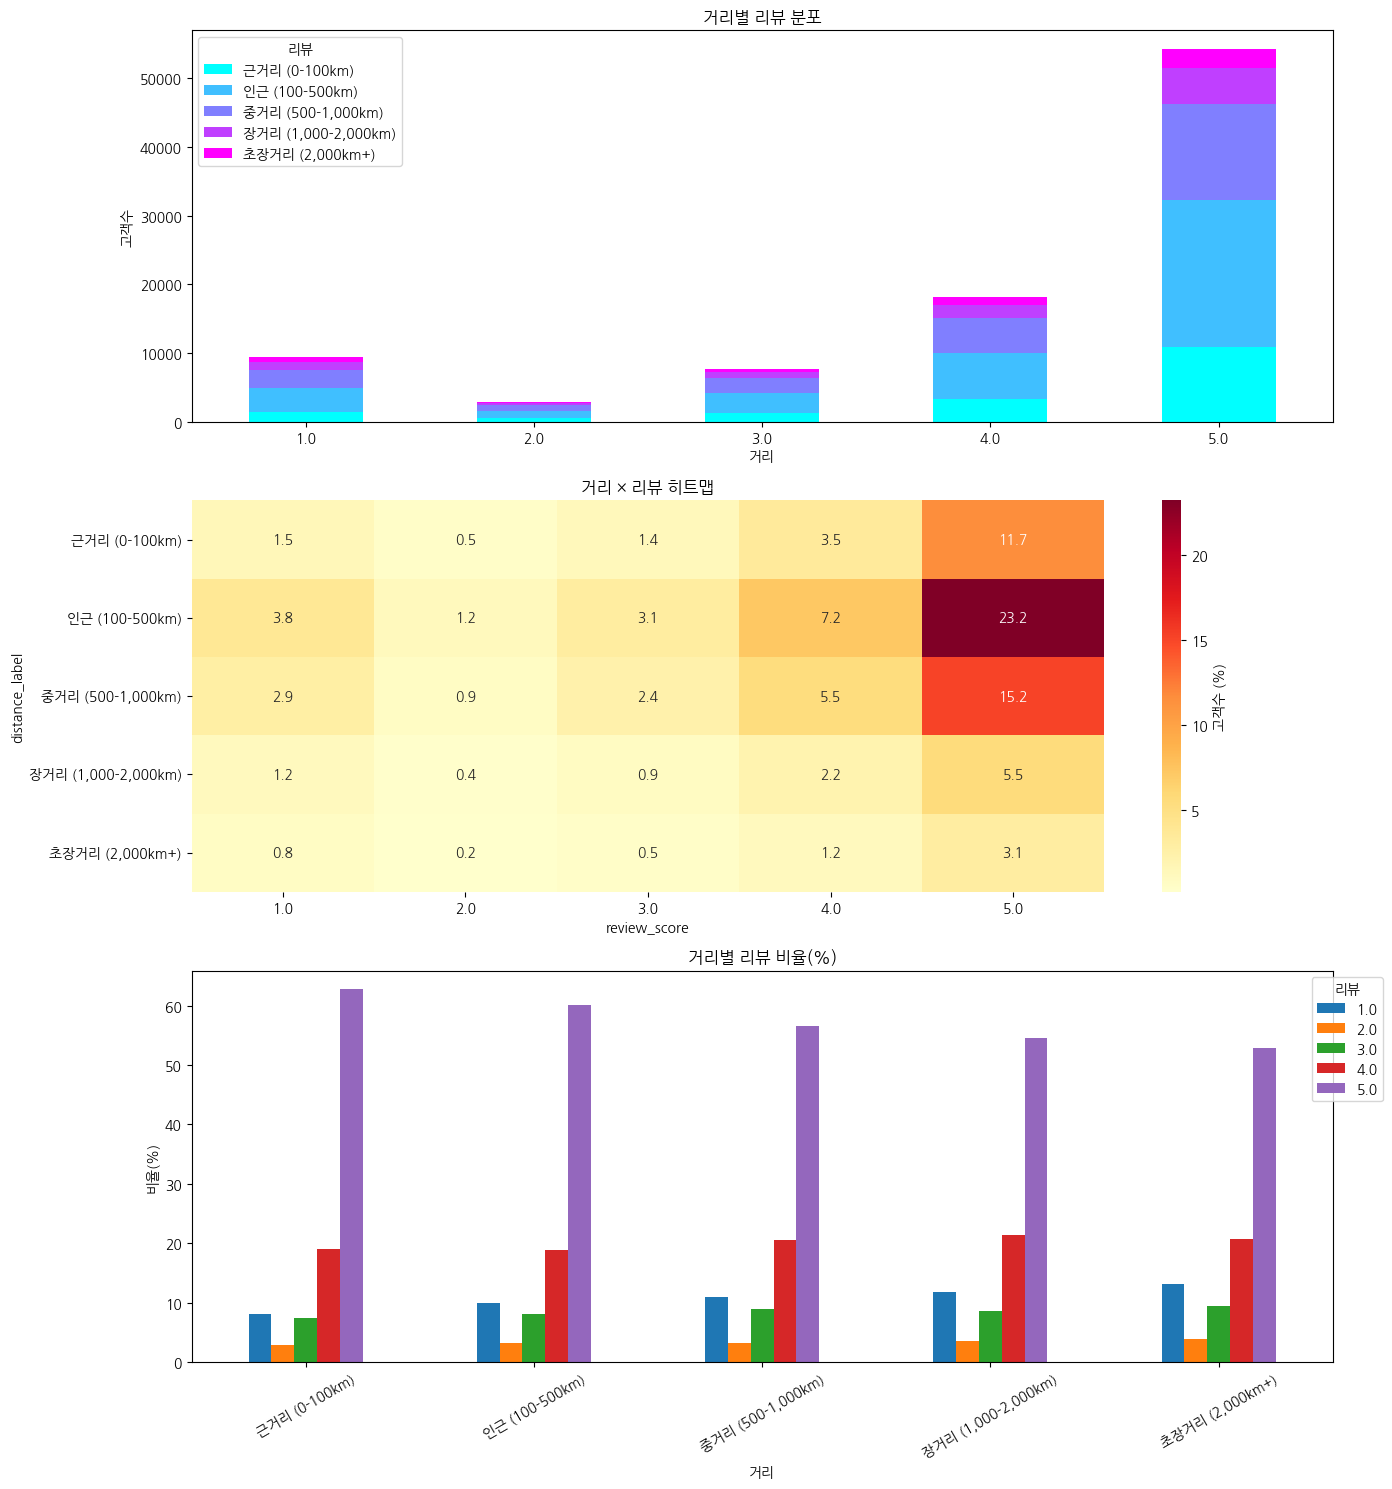

In [55]:
# 색상 목록 정의 (RGB 튜플 또는 16진수 코드 사용)
distance_colormap = 'cool'

review_colormap = 'hot'

var1 = '거리'
var2 = '리뷰'
label = '고객수'


# 데이터 시각화
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# 누적 막대그래프
plot_stacked_bar(dist_review_data, axes[0], var1, var2, label, cmap=distance_colormap)

# 히트맵 -> 비율 or 스케일링해서 보여주면 될 것 같다.
plot_heatmap(dist_review_data, axes[1], var1, var2, label, normalize='all')


# 비율 막대그래프
plot_prop_bar(dist_review_data, axes[2], var1, var2, cmap=review_colormap, xrotation=30)


plt.tight_layout()
plt.show()

In [56]:
# 기대빈도 확인 (카이제곱 적절성 판단)
is_valid = check_expected_frequencies(dist_review_data)


[기대빈도 확인]
----------------------------------------
최소 기대빈도: 170.63
5 미만 셀: 0/25 (0.0%)
✅ 카이제곱검정 사용 가능


In [57]:
# 적절한 검정 선택 및 수행 

print("\n[카이제곱 독립성 검정]")
print('-'*40)

alpha = 0.05

# 가설 설정
print(f"H₀: {var1} & {var2} - 독립적이다")
print(f"H₁: {var1} & {var2} - 관련이 있다")
print(f"유의수준: α = {alpha}")


chi2_stat, p_value, dof, expected = chi2_contingency(dist_review_data)

print(f"\n카이제곱 통계량: {chi2_stat:.4f}")
print(f"자유도: {dof}")  # df = (행수-1) × (열수-1)
print(f"p-value: {p_value:.4f}")


[카이제곱 독립성 검정]
----------------------------------------
H₀: 거리 & 리뷰 - 독립적이다
H₁: 거리 & 리뷰 - 관련이 있다
유의수준: α = 0.05

카이제곱 통계량: 398.0664
자유도: 16
p-value: 0.0000


In [58]:
# 효과 크기 계산

n = dist_review_data.values.sum()
r, c = dist_review_data.shape
v = cramers_v(chi2_stat, n, r, c)

print(f"Cramér's V: {v:.3f} ({interpret_cramers_v(v)})")

Cramér's V: 0.033 (매우 약한 관계)


In [59]:
# 잔차 분석 또는 Odds 분석 (필요한 경우)

expected_df = pd.DataFrame(expected, 
                           index=dist_review_data.index,
                           columns=dist_review_data.columns)
print("\n[기대빈도]")
display(expected_df.round(2))


# 각 셀이 독립성 가정에서 얼마나 벗어났는지 측정
# 표준화 잔차 = (관측값 - 기대값) / sqrt(기대값)
std_residuals = standardized_residuals(dist_review_data.values, expected)
residuals_df = pd.DataFrame(std_residuals,
                            index=dist_review_data.index,
                            columns=dist_review_data.columns)
print("\n[표준화 잔차]")
display(residuals_df.round(2))
print("(|잔차| > 2: 유의한 차이, |잔차| > 3: 매우 강한 연관성)")


[기대빈도]


review_score,1.0,2.0,3.0,4.0,5.0
distance_label,,,,,
근거리 (0-100km),1754.31,548.56,1432.89,3383.04,10107.19
인근 (100-500km),3633.89,1136.29,2968.10,7007.64,20936.08
"중거리 (500-1,000km)",2527.29,790.26,2064.24,4873.65,14560.56
"장거리 (1,000-2,000km)",953.84,298.26,779.08,1839.40,5495.41
"초장거리 (2,000km+)",545.66,170.63,445.69,1052.27,3143.76



[표준화 잔차]


review_score,1.0,2.0,3.0,4.0,5.0
distance_label,,,,,
근거리 (0-100km),-8.82,-2.29,-4.28,-2.06,7.01
인근 (100-500km),-1.81,-0.42,-1.18,-3.68,3.42
"중거리 (500-1,000km)",3.32,-0.12,3.05,2.98,-4.23
"장거리 (1,000-2,000km)",4.86,2.01,1.04,3.86,-5.12
"초장거리 (2,000km+)",6.91,2.78,2.76,1.66,-5.52


(|잔차| > 2: 유의한 차이, |잔차| > 3: 매우 강한 연관성)


In [60]:
# 해석

print("\n[결론]")

# p-value를 유의수준과 비교하여 가설 채택/기각 결정
if p_value < 0.05:
    print(f"✅ p-value({p_value:.4f}) < 0.05 → 귀무가설 기각")
    print(f"   {var1} & {var2} - 관련이 있다")
    print(f"   효과 크기: {interpret_cramers_v(v)}")
    
    # -------------------------------------------------------------------------
    # 6. 사후 분석 (Post-hoc Analysis)
    # -------------------------------------------------------------------------
    # 표준화 잔차를 통해 어느 조합이 특히 연관성이 강한지 분석
    print("\n[구체적 패턴 분석]")
    print("   표준화 잔차 |값| > 2인 셀 해석:")
    
    for i, grade in enumerate(dist_review_data.index):
        for j, lang in enumerate(dist_review_data.columns):
            # |잔차| > 2: 해당 조합이 독립성에서 유의하게 벗어남
            if abs(std_residuals[i, j]) > 2:
                if std_residuals[i, j] > 0:
                    # 양수: 관측값 > 기대값 (과대 표현)
                    print(f"   • {grade} - {lang}: 예상보다 높음 (잔차={std_residuals[i, j]:.2f})")
                else:
                    # 음수: 관측값 < 기대값 (과소 표현)
                    print(f"   • {grade} - {lang}: 예상보다 낮음 (잔차={std_residuals[i, j]:.2f})")
else:
    print(f"❌ p-value({p_value:.4f}) ≥ 0.05 → 귀무가설 채택")
    print(f"   {var1} & {var2} - 독립적이다")
    print(f"   ({var1} -> {var2}에 영향을 주지 않음)")


[결론]
✅ p-value(0.0000) < 0.05 → 귀무가설 기각
   거리 & 리뷰 - 관련이 있다
   효과 크기: 매우 약한 관계

[구체적 패턴 분석]
   표준화 잔차 |값| > 2인 셀 해석:
   • 근거리 (0-100km) - 1.0: 예상보다 낮음 (잔차=-8.82)
   • 근거리 (0-100km) - 2.0: 예상보다 낮음 (잔차=-2.29)
   • 근거리 (0-100km) - 3.0: 예상보다 낮음 (잔차=-4.28)
   • 근거리 (0-100km) - 4.0: 예상보다 낮음 (잔차=-2.06)
   • 근거리 (0-100km) - 5.0: 예상보다 높음 (잔차=7.01)
   • 인근 (100-500km) - 4.0: 예상보다 낮음 (잔차=-3.68)
   • 인근 (100-500km) - 5.0: 예상보다 높음 (잔차=3.42)
   • 중거리 (500-1,000km) - 1.0: 예상보다 높음 (잔차=3.32)
   • 중거리 (500-1,000km) - 3.0: 예상보다 높음 (잔차=3.05)
   • 중거리 (500-1,000km) - 4.0: 예상보다 높음 (잔차=2.98)
   • 중거리 (500-1,000km) - 5.0: 예상보다 낮음 (잔차=-4.23)
   • 장거리 (1,000-2,000km) - 1.0: 예상보다 높음 (잔차=4.86)
   • 장거리 (1,000-2,000km) - 2.0: 예상보다 높음 (잔차=2.01)
   • 장거리 (1,000-2,000km) - 4.0: 예상보다 높음 (잔차=3.86)
   • 장거리 (1,000-2,000km) - 5.0: 예상보다 낮음 (잔차=-5.12)
   • 초장거리 (2,000km+) - 1.0: 예상보다 높음 (잔차=6.91)
   • 초장거리 (2,000km+) - 2.0: 예상보다 높음 (잔차=2.78)
   • 초장거리 (2,000km+) - 3.0: 예상보다 높음 (잔차=2.76)
   • 초장거리 (2,000km+) - 5.0: 예상보다 낮음

## 결론

거리는 리뷰 점수와 통계적으로 관련이 있지만, 실제 영향력은 무시할 수 있을 만큼 작다